# Country weekly EDA
Utforskar data för alla länder.

In [87]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

# Läs in datat
DATA_PATH = Path("../../data/processed")
df = pd.read_csv(DATA_PATH / "2026-02-08_country_weekly.csv", sep=';', encoding='utf-8')

# Skapa media_type-kolumn
df['media_type'] = df['category'].apply(lambda x: 'Film' if 'Films' in x else 'TV')
# Skapa language-kolumn
df['language'] = df['category'].apply(lambda x: 'English' if 'English' in x else 'Non-English')

# Konvertera runtime, svenska decimaler med komma, till float
df['runtime'] = df['runtime'].astype(str).str.replace(',', '.').astype(float)

# Registrera i DuckDB
duckdb.register("country_weekly", df)

# Stil
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("Data laddad. Antal rader:", len(df))
print("Kolumner:", df.columns.tolist())

Data laddad. Antal rader: 40
Kolumner: ['category', 'rank', 'show_title', 'season_title', 'hours_viewed_first_91_days', 'runtime', 'views_first_91_days', 'media_type', 'language']


### Skapar querys, visualiseringar och använder duckdb 

1. Fördelning film/TV: antal titlar och total visningstimmar

In [88]:
# Analysera fördelningen av filmer vs TV-serier i country_weekly
result = duckdb.sql("""
    SELECT 
        media_type,
        COUNT(*) AS antal_titlar,
        SUM(hours_viewed_first_91_days) AS total_hours,
        SUM(views_first_91_days) AS total_views
    FROM country_weekly
    GROUP BY media_type
""").df()

print("=== Fördelning film vs TV ===\n")
for _, row in result.iterrows():
    print(f"{row['media_type']}: {row['antal_titlar']} titlar, "
          f"{row['total_hours']/1e6:.1f}M timmar, {row['total_views']/1e6:.1f}M visningar")

=== Fördelning film vs TV ===

TV: 20 titlar, 18646.4M timmar, 2519.1M visningar
Film: 20 titlar, 5032.4M timmar, 2624.5M visningar


2. De totala visningarna, film vs tv-series

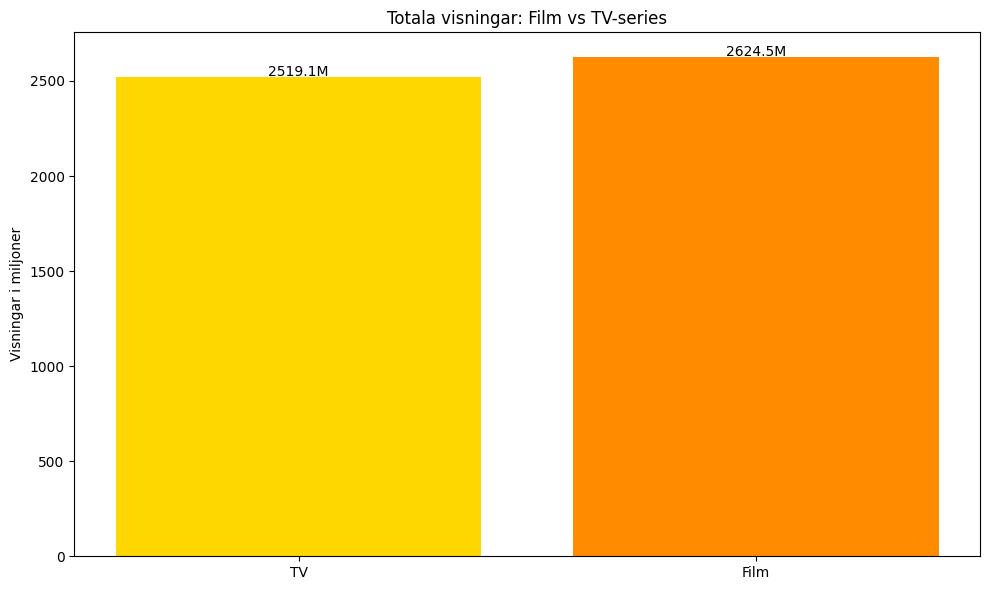

In [89]:
plt.bar(result['media_type'], result['total_views'] / 1e6, color=['gold', 'darkorange'])
plt.ylabel('Visningar i miljoner')
plt.title('Totala visningar: Film vs TV-series')
for i, v in enumerate(result['total_views'] / 1e6):
    plt.text(i, v + 5, f'{v:.1f}M', ha='center')
plt.tight_layout()
plt.show()

3. Topp 10 filmer de första 91 dagarna, baserat på visningar

In [90]:
# Med hjälp av hours_viewed_first_91_days och views_first_91_days, analysera de 10 mest sedda filmerna
top_films = duckdb.sql("""
    SELECT 
        show_title,
        category,
        hours_viewed_first_91_days / 1e6 AS hours_millions,
        views_first_91_days / 1e6 AS views_millions,
        runtime
    FROM country_weekly
    WHERE media_type = 'Film'
    ORDER BY views_first_91_days DESC
    LIMIT 10
""").df()

print("\n=== Topp 10 filmer globalt ===\n")
print("Topp 10 filmer: ")
print(top_films[['show_title', 'category', 'views_millions', 'hours_millions', 'runtime']])



=== Topp 10 filmer globalt ===

Topp 10 filmer: 
               show_title         category  views_millions  hours_millions  \
0      KPop Demon Hunters  Films (English)           325.1           541.8   
1              Red Notice  Films (English)           230.9           454.2   
2                Carry-On  Films (English)           172.1           344.1   
3           Don't Look Up  Films (English)           171.4           408.6   
4        The Adam Project  Films (English)           157.6           281.0   
5                Bird Box  Films (English)           157.4           325.3   
6          Back in Action  Films (English)           147.2           279.7   
7  Leave the World Behind  Films (English)           143.4           339.3   
8            The Gray Man  Films (English)           139.3           299.5   
9                  Damsel  Films (English)           138.0           253.0   

   runtime  
0   1.6667  
1   1.9667  
2   2.0000  
3   2.3833  
4   1.7833  
5   2.0667  


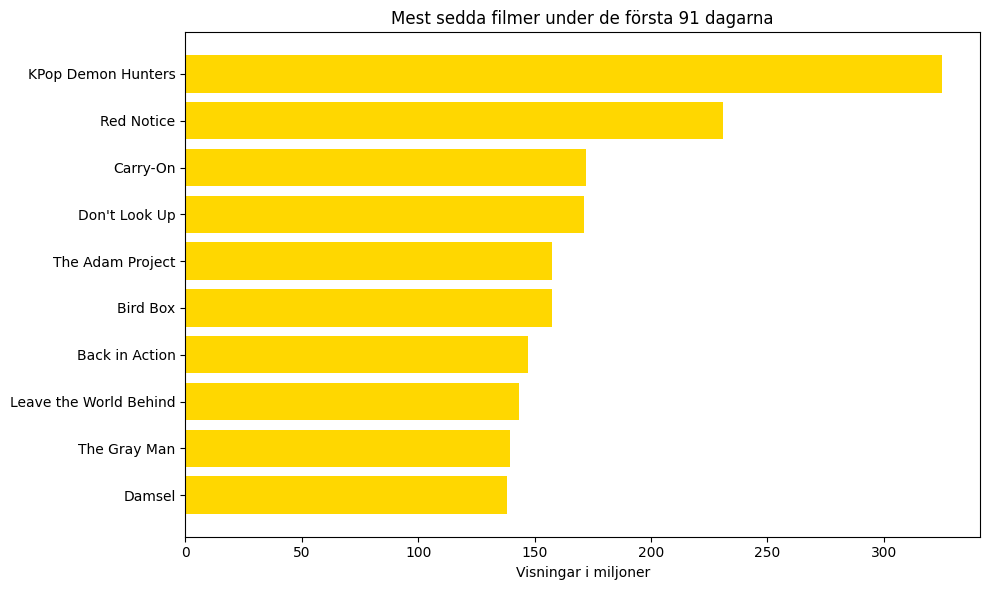

In [91]:
plt.barh(top_films['show_title'], top_films['views_millions'], color='gold')
plt.xlabel('Visningar i miljoner')
plt.title('Mest sedda filmer under de första 91 dagarna')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

4. Språkjämförelse i visningar på English vs Non-English, film/tv-serie

In [92]:
# Gruppera direkt på category
cat_views = duckdb.sql("""
    SELECT 
        category,
        SUM(views_first_91_days) / 1e6 AS total_views_millions
    FROM country_weekly
    GROUP BY category
    ORDER BY total_views_millions DESC
""").df()
print(cat_views)

              category  total_views_millions
0      Films (English)                1782.4
1         TV (English)                1333.7
2     TV (Non-English)                1185.4
3  Films (Non-English)                 842.1


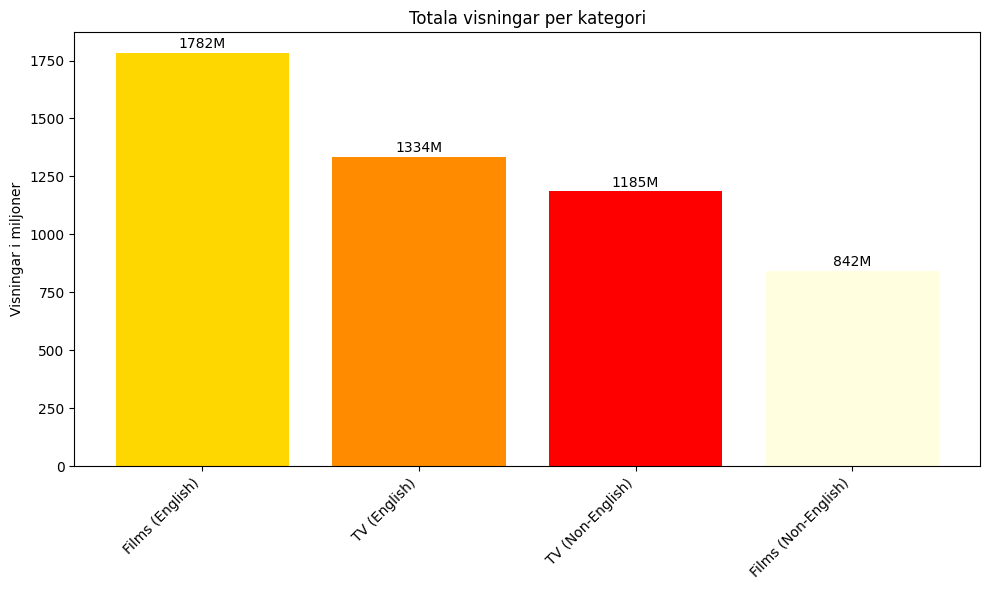

In [93]:
plt.bar(cat_views['category'], cat_views['total_views_millions'], color=['gold', 'darkorange', 'red', 'lightyellow'])
plt.ylabel('Visningar i miljoner')
plt.title('Totala visningar per kategori')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(cat_views['total_views_millions']):
    plt.text(i, v + 20, f'{v:.0f}M', ha='center')
plt.tight_layout()
plt.show()

5. Samband mellan speltid "runtime" och visningar

In [94]:
data = duckdb.sql("""
    SELECT 
        media_type,
        runtime,
        views_first_91_days / 1e6 AS views_millions
    FROM country_weekly
    WHERE runtime IS NOT NULL
""").df()

films = data[data['media_type'] == 'Film']
tvs = data[data['media_type'] == 'TV']

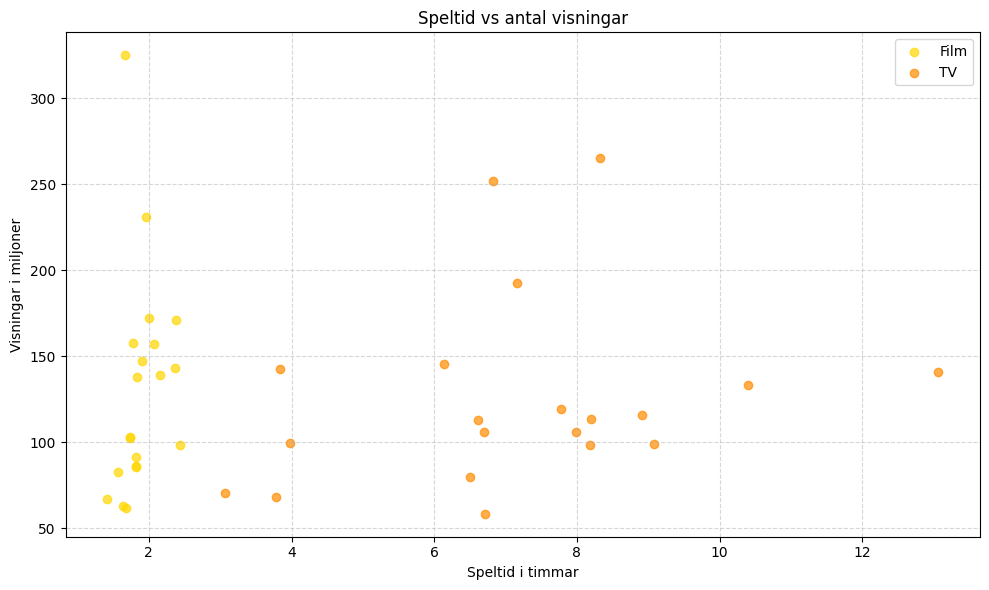

In [95]:
plt.scatter(films['runtime'], films['views_millions'], label='Film', alpha=0.7, color='gold')
plt.scatter(tvs['runtime'], tvs['views_millions'], label='TV', alpha=0.7, color='darkorange')
plt.xlabel('Speltid i timmar')
plt.ylabel('Visningar i miljoner')
plt.title('Speltid vs antal visningar')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

6. TV-serier med flera säsonger, till exempel: Squid Game, Money Heist, Stranger Things

In [96]:
multi_season = duckdb.sql("""
    SELECT 
        show_title,
        season_title,
        views_first_91_days / 1e6 AS views_millions
    FROM country_weekly
    WHERE media_type = 'TV' 
      AND show_title IN ('Squid Game', 'Money Heist', 'Stranger Things')
    ORDER BY show_title, season_title
""").df()
print(multi_season)

        show_title          season_title  views_millions
0      Money Heist   Money Heist: Part 3            80.0
1      Money Heist   Money Heist: Part 4           106.0
2      Money Heist   Money Heist: Part 5            99.2
3       Squid Game  Squid Game: Season 1           265.2
4       Squid Game  Squid Game: Season 2           192.6
5       Squid Game  Squid Game: Season 3           145.8
6  Stranger Things     Stranger Things 4           140.7
7  Stranger Things     Stranger Things 5           133.1


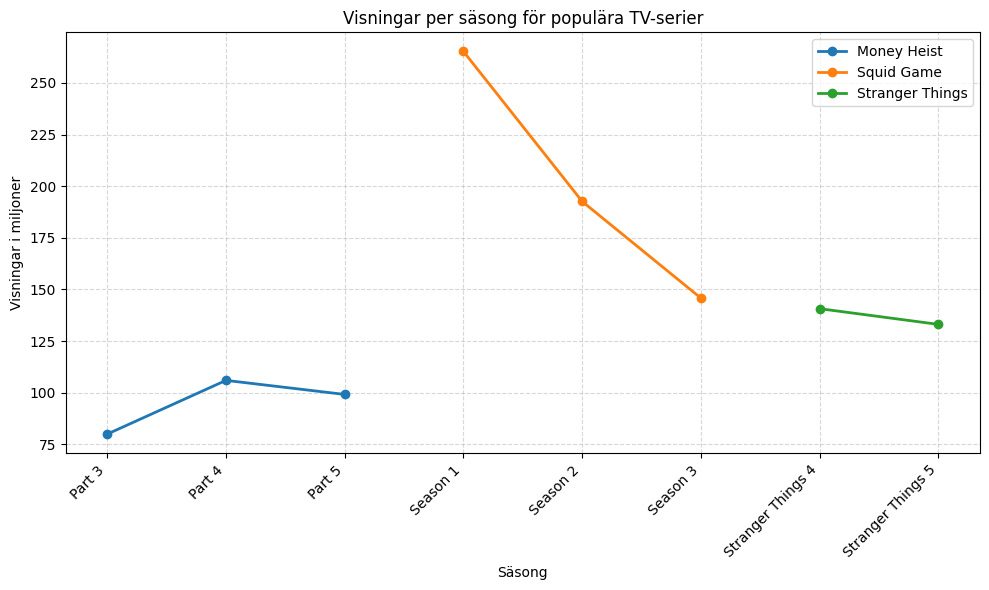

In [97]:
fig, ax = plt.subplots()
for title in multi_season['show_title'].unique():
    subset = multi_season[multi_season['show_title'] == title]
    # Skapa säsongsnummer 
    seasons = [s.split(':')[-1].strip() for s in subset['season_title']]
    ax.plot(seasons, subset['views_millions'], marker='o', label=title, linewidth=2)
ax.set_xlabel('Säsong')
ax.set_ylabel('Visningar i miljoner')
ax.set_title('Visningar per säsong för populära TV-serier')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

7. Andel av totala visningar per kategori

In [98]:
cat_shares = duckdb.sql("""
    SELECT 
        category,
        SUM(views_first_91_days) AS total_views
    FROM country_weekly
    GROUP BY category
    ORDER BY total_views DESC
""").df()
cat_shares['share'] = cat_shares['total_views'] / cat_shares['total_views'].sum()
print(cat_shares[['category', 'share']])

              category     share
0      Films (English)  0.346528
1         TV (English)  0.259293
2     TV (Non-English)  0.230461
3  Films (Non-English)  0.163718


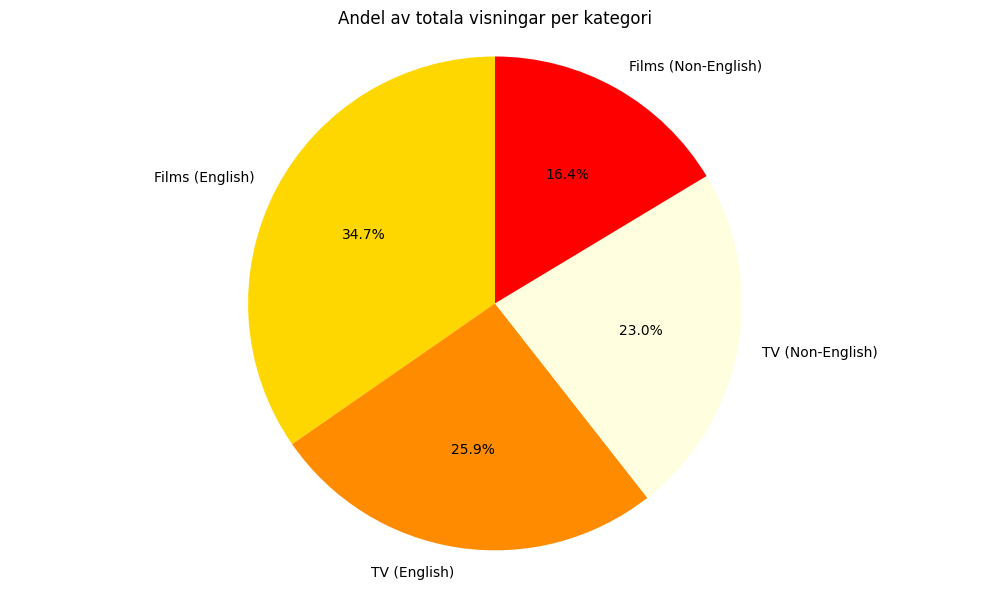

In [99]:
plt.pie(cat_shares['share'], labels=cat_shares['category'], autopct='%1.1f%%', 
        startangle=90, colors=['gold', 'darkorange', 'lightyellow', 'red'])
plt.title('Andel av totala visningar per kategori')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Sammanfattning
Vad datan säger.
- *Film vs TV*: Lika många titlar, men TV-serier står för nästan fyra gånger fler visningstimmar trots nästan identiskt antal visningar.
- *Toppfilmer*: Kpop Demon Hunters är mest sedd, följt av Red Notice.
- *Språkfördelning*: Engelska filmer dominerar andelen av totala visningar 34.7%, därefter engelska TV-serier 25.9%. Icke-engelskt innehåll står för knappt 40 % av visningarna, fördelat relativt jämnt mellan film och TV.
- *Säsongstrender*: För populära serier som Squid Game sjunker visningarna successivt över säsongerna. 
- *Speltid vs visningar*: TV-serier har generellt längre speltid än filmer, men visningarna varierar stort.